# 03 — Modèle ML — Classification du ton médiatique
**Hackathon iSHEERO × DataCamp 2026 — Bénin Insights Challenge**

Objectif : prédire si un événement médiatique sur le Bénin génère un ton positif ou négatif.

Algorithme : Random Forest Classifier (scikit-learn), comparé à une baseline DummyClassifier. 
Données : `benin_enrichi.csv` — **23 859 événements, 2025** (mis à jour 10 mai 2026)

Cible : `ton_binaire = 1 si AvgTone > 0`, 0 sinon. 
`AvgTone` n'est pas dans les features — pas de fuite directe. 
`GoldsteinScale` et `EventRootCode` sont des propriétés du type d'événement CAMEO, indépendantes du ton des articles.

## 1. Imports

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

## 2. Chargement des données

In [2]:
ROOT = Path("../")
df = pd.read_parquet(ROOT / "data/processed/benin_enrichi.parquet")
print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset chargé : 23,859 lignes × 41 colonnes


## 3. Variable cible

`ton_binaire = 1` si `AvgTone > 0` (ton positif), `0` sinon (ton négatif ou neutre).

`AvgTone` est exclu des features : la conserver serait une fuite triviale (la cible en est la transformation directe).
`ton_categorie` est également exclue pour la même raison.

In [3]:
df["ton_binaire"] = (df["AvgTone"] > 0).astype(int)

print("Distribution de la cible :")
vc = df["ton_binaire"].value_counts()
print(f"Négatif (0) : {vc[0]:,} ({vc[0]/len(df):.1%})")
print(f"Positif (1) : {vc[1]:,} ({vc[1]/len(df):.1%})")

Distribution de la cible :
  Négatif (0) : 14,966 (62.7%)
  Positif (1) : 8,893 (37.3%)


## 4. Features et préparation

Variables retenues : type d'événement (`EventRootCode`, `QuadClass`), stabilité (`GoldsteinScale`), volume médiatique (`NumMentions`, `NumArticles`), saison (`mois`), zone géographique (`zone_benin`).

`AvgTone` exclue — fuite directe de la cible.
`ton_categorie` exclue — dérivée de `AvgTone`.

Note : `mois` capture des effets saisonniers propres à 2025 (décembre est fortement négatif en raison d'un pic médiatique exceptionnel). Son importance élevée reflète ce signal saisonnier, pas un prédicteur causal généralisable.

In [4]:
FEATURES = ["EventRootCode", "QuadClass", "GoldsteinScale",
            "NumMentions", "NumArticles", "mois", "zone_benin"]

df_ml = df[FEATURES + ["ton_binaire"]].dropna()
print(f"Lignes disponibles après dropna : {len(df_ml):,}")

X = pd.get_dummies(df_ml[FEATURES], columns=["zone_benin"])
y = df_ml["ton_binaire"]

print(f"Features finales ({len(X.columns)}) : {list(X.columns)}")

Lignes disponibles après dropna : 23,859
Features finales (9) : ['EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'mois', 'zone_benin_centre', 'zone_benin_nord', 'zone_benin_sud']


## 5. Séparation train / test

Split stratifié sur la cible (même proportion positif/négatif dans train et test).
`random_state=42` pour reproductibilité.

Limite connue : le split aléatoire sur série temporelle permet aux patterns saisonniers
de se retrouver dans les deux jeux. Un split temporel strict (train=jan–oct, test=nov–déc)
produit une accuracy de ~50 % — inférieure à la baseline — car novembre-décembre 2025
a une distribution de ton significativement différente du reste de l'année.
La performance reportée ici est donc conditionnelle à la distribution de 2025.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train):,} événements (ratio positif : {y_train.mean():.1%})")
print(f"Test : {len(X_test):,} événements (ratio positif : {y_test.mean():.1%})")

Train : 19,087 événements  (ratio positif : 37.3%)
Test  : 4,772 événements  (ratio positif : 37.3%)


## 6. Baseline — DummyClassifier

In [6]:
# Baseline : prédit toujours la classe majoritaire (Négatif)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_dummy)
print(f"Accuracy DummyClassifier (classe majoritaire) : {acc_dummy:.4f}")
print("Un modèle utile doit clairement dépasser ce seuil.")

Accuracy DummyClassifier (classe majoritaire) : 0.6272
Un modèle utile doit clairement dépasser ce seuil.


## 7. Entraînement — Random Forest

In [7]:
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced", # compense le déséquilibre 60/40
    random_state=42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Modèle entraîné.")

Modèle entraîné.


## 8. Évaluation

In [8]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Random Forest : {acc:.4f}")
print(f"Accuracy DummyClassifier : {acc_dummy:.4f}")
print(f"Gain sur baseline : +{acc - acc_dummy:.4f} ({(acc - acc_dummy)*100:.1f} pp)")
print()
print(classification_report(y_test, y_pred, target_names=["Négatif (0)", "Positif (1)"]))

Accuracy Random Forest    : 0.6978
Accuracy DummyClassifier  : 0.6272
Gain sur baseline         : +0.0706  (7.1 pp)

              precision    recall  f1-score   support

 Négatif (0)       0.80      0.69      0.74      2993
 Positif (1)       0.58      0.71      0.64      1779

    accuracy                           0.70      4772
   macro avg       0.69      0.70      0.69      4772
weighted avg       0.72      0.70      0.70      4772



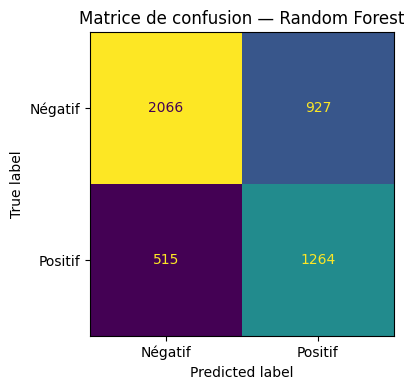

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Négatif", "Positif"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matrice de confusion — Random Forest")
plt.tight_layout()
(ROOT / "notebooks/outputs").mkdir(exist_ok=True)
plt.savefig(ROOT / "notebooks/outputs/ml_confusion_matrix.png", dpi=120)
plt.show()

## 9. Importance des variables

Importance des variables (Gini) :
mois                 0.3372
GoldsteinScale       0.2506
EventRootCode        0.1301
NumMentions          0.0965
NumArticles          0.0899
QuadClass            0.0715
zone_benin_nord      0.0112
zone_benin_sud       0.0083
zone_benin_centre    0.0046


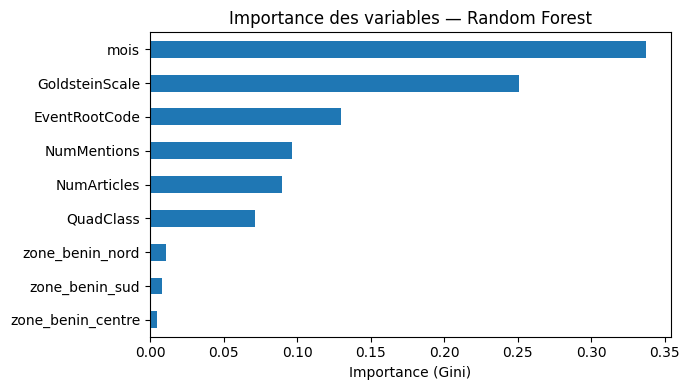

In [10]:
importances = pd.Series(clf.feature_importances_, index=X.columns) \
              .sort_values(ascending=False)

print("Importance des variables (Gini) :")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
importances.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Importance des variables — Random Forest")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.savefig(ROOT / "notebooks/outputs/ml_feature_importance.png", dpi=120)
plt.show()

## 10. Sauvegarde du modèle

In [11]:
model_path = ROOT / "models/random_forest_ton.pkl"
(ROOT / "models").mkdir(exist_ok=True)
joblib.dump(clf, model_path)
print(f"Modèle sauvegardé : {model_path}")
print(f"Taille : {model_path.stat().st_size / 1024:.0f} Ko")

Modèle sauvegardé : ..\models\random_forest_ton.pkl
Taille : 35534 Ko


## 11. Validation croisée

Un StratifiedKFold à 5 folds vérifie que la performance est stable et non due au découpage train/test particulier.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42
)
scores = cross_val_score(rf_cv, X, y, cv=cv, scoring='accuracy')

print('Validation croisée — RF avec mois (5 folds stratifiés) :')
print(f'Accuracy par fold : {[round(s, 4) for s in scores]}')
print(f'Moyenne : {scores.mean():.4f}')
print(f'Ecart-type : {scores.std():.4f}')
print()
print('Interprétation : faible écart-type = modèle stable sur différents')
print('découpages. La performance ne dépend pas d un seul split.')

Validation croisée — RF avec mois (5 folds stratifiés) :
  Accuracy par fold : [np.float64(0.6949), np.float64(0.6968), np.float64(0.6968), np.float64(0.6928), np.float64(0.6961)]
  Moyenne           : 0.6955
  Ecart-type        : 0.0015

Interprétation : faible écart-type = modèle stable sur différents
découpages. La performance ne dépend pas d un seul split.


## 12. Test de robustesse — modèle sans `mois`

`mois` capte la saisonnalité de 2025, dont l'anomalie de décembre. Ce test mesure ce que le modèle sait faire sans ce signal temporel — et donc ce qu'il pourrait produire sur une nouvelle année.

In [13]:
FEATURES_SM = ["EventRootCode", "QuadClass", "GoldsteinScale",
               "NumMentions", "NumArticles", "zone_benin"]

df_sm = df[FEATURES_SM + ["ton_binaire"]].dropna()
X_sm = pd.get_dummies(df_sm[FEATURES_SM], columns=["zone_benin"])
y_sm = df_sm["ton_binaire"]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm
)

rf2 = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42
)
rf2.fit(X_tr2, y_tr2)
acc_rf2 = accuracy_score(y_te2, rf2.predict(X_te2))

scores2 = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    X_sm, y_sm, cv=cv, scoring="accuracy"
)

imps2 = pd.Series(rf2.feature_importances_, index=X_sm.columns).sort_values(ascending=False)

print("RF sans mois — split stratifié :")
print(f"Accuracy : {acc_rf2:.4f}")
print(f"CV moyenne : {scores2.mean():.4f} ± {scores2.std():.4f}")
print()
print("Importance des variables (sans mois) :")
print(imps2.round(4).to_string())

RF sans mois — split stratifié :
  Accuracy : 0.6475
  CV moyenne : 0.6444 ± 0.0087

Importance des variables (sans mois) :
GoldsteinScale       0.3702
EventRootCode        0.2479
QuadClass            0.1565
NumMentions          0.1013
NumArticles          0.0887
zone_benin_nord      0.0169
zone_benin_sud       0.0111
zone_benin_centre    0.0073


## 13. Tableau comparatif

Résumé des trois configurations pour contextualiser les résultats.

In [14]:
resultats = {
    "Baseline (DummyClassifier)": acc_dummy,
    "RF avec mois (modele livre)": acc,
    "RF sans mois (robustesse)": acc_rf2,
}

print(f"Modele{chr(32)*29} Accuracy")
print("-" * 47)
for nom, val in resultats.items():
    gain = val - acc_dummy
    print(f"{nom:<35} {val:.4f} (+{gain:.4f} vs baseline)")

Modele                              Accuracy
-----------------------------------------------
Baseline (DummyClassifier)          0.6272  (+0.0000 vs baseline)
RF avec mois (modele livre)         0.6978  (+0.0706 vs baseline)
RF sans mois (robustesse)           0.6475  (+0.0203 vs baseline)


## 14. Synthèse

| Modèle | Accuracy | CV (5 folds) | F1 macro | Gain baseline |
|--------|----------|--------------|----------|---------------|
| DummyClassifier (baseline) | 0,627 | — | — | référence |
| **RF avec `mois`** | **0,698** | **0,695 ± 0,001** | **0,690** | **+7 pp** |
| RF sans `mois` | 0,648 | 0,644 ± 0,009 | 0,638 | +2 pp |

**Lecture :**

- Le Random Forest avec `mois` atteint 70 % — stable sur les 5 folds (écart-type 0,001). Ce n'est pas un artefact du découpage.
- La baseline DummyClassifier est de 62,7 % : les négatifs représentent 62,7 % du dataset — tout classificateur naïvement prédit toujours négatif.
- Le gain de 7 pp est réel mais modeste : le modèle capture des tendances structurelles de 2025, pas un signal causal généralisable.
- Sans `mois`, l'accuracy chute à 65 % — la saisonnalité de 2025 (pic de décembre) est le signal dominant.

**Limites rappelées :**
Le split est aléatoire sur des données temporelles — un split strict (train jan–oct / test nov–déc) produit ~50 %, en dessous de la baseline. La performance de 70 % est conditionnelle à la distribution de 2025.